# Data Extraction

In [6]:
import obspy, io, subprocess, utils, os, logging, re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import obspy.core.utcdatetime as utc
from obspy.clients.fdsn import Client
from eqcct.stream import st_predictor

WIN_SIZE = 60               # Window size in seconds. Same window size used in EQCCT paper
PRE_EVENT_BUFFER = 5        # Number of seconds from start of window until first pick
POST_EVENT_BUFFER = 5       # Number of seconds from last pick until end of window

## Opening large mseed files
`obspy.read()` cannot directly read mini-SEED files that are larger than 2048 MB. Read the file in chunks instead ([link](https://github.com/obspy/obspy/pull/1419#issuecomment-221582369) to github issue).

Note on `record_len`: A record is a unit of data in the miniSEED format. A record consists of a certain number of data points in the waveform. Typical record lengths for raw data generation and archiving are between 256 and 4096 bytes ([FDSN docs](https://docs.fdsn.org/projects/miniseed3/en/latest/definition.html#:~:text=typical%20record%20lengths%20for%20raw%20data%20generation%20and%20archiving%20are%20recommended%20to%20be%20in%20the%20range%20of%20256%20and%204096%20bytes)).

In [7]:
mseed_filename = "HE_020125_030125.mseed" # Queried from ISUH FDSNWS. It is a 3.7GB file containing waveforms from HE network from 2-3 Jan 2025
data_dir = Path(utils.DATA_DIR)

record_len = 512
chunksize = 100000 * record_len
with io.open(data_dir / mseed_filename, "rb") as fh:
    while True:
        with io.BytesIO() as buf:
            c = fh.read(chunksize)
            if not c:
                break
            buf.write(c)
            buf.seek(0, 0)
            st = obspy.read(buf)
        # Do something useful!
        print(st)
        break # We just want to see the first stream from the mseed file

2 Trace(s) in Stream:
HE.OBF8..HHE | 2025-01-01T23:59:59.568000Z - 2025-01-03T00:00:00.748000Z | 250.0 Hz, 21600296 samples
HE.OBF8..HHN | 2025-01-01T23:59:58.808000Z - 2025-01-02T07:26:55.188000Z | 250.0 Hz, 6704096 samples


## Querying waveform data from ISUH FDSNWS

To query ISUH FDSNWS dataselect service, ensure your device is connected to the university's network. Eduroam does not work, but wired connections on devices at the university do.

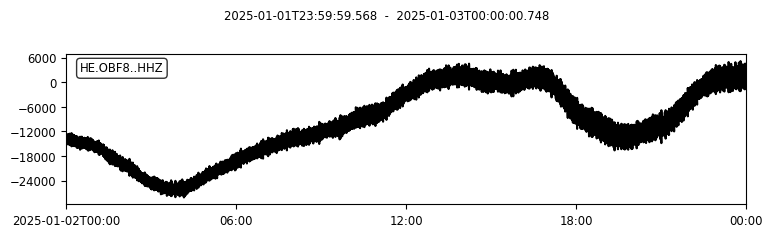

In [8]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime


client = Client(utils.ISUH_IP_ADDR) # ISUH FDSNWS IP address

start_time = UTCDateTime("2025-01-01T23:59:59.568000Z")
end_time = UTCDateTime("2025-01-03T00:00:00.748000Z")

st = client.get_waveforms("HE", "OBF8", "*", "HHZ", start_time, end_time)

st.plot()
plt.show() # Run this to prevent the figure from being rendering twice

## Creating waveform dataset

#### 1. Extract pick information from quakeML files into `df_pick`

Takes 6.5 min to run.

In [9]:
data_dir = Path(utils.DATA_DIR)

paths = {
    "earthquakes": data_dir / "earthquakes2025.qkml",
    "explosions": data_dir / "explosions2025.qkml",
    "probable_explosions": data_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = obspy.read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

# Dataframe of all earthquake, explosion and probable_explosion picks               
df_picks = utils.extract_picks(catalogs)
# df_picks.to_csv(utils.FILENAME_PICKS) # Export to csv for possible debugging

print(f"\nTotal number of picks: {len(df_picks)}\n")
print(df_picks["Event type"].value_counts().to_frame(name="Number of picks"))
df_picks.head()

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml

Total number of picks: 54134

                     Number of picks
probable_explosions            32720
explosions                     14281
earthquakes                     7133


,Event id,SEED string,Pick type,Event type,Pick time
0,smi:fi.isuh/event/1490639,UP.LANU..BHZ,P,earthquakes,2025-01-01T09:22:01.256470Z
1,smi:fi.isuh/event/1490639,UP.LANU..BHZ,S,earthquakes,2025-01-01T09:22:07.069410Z
2,smi:fi.isuh/event/1490639,HE.HEF..BHZ,P,earthquakes,2025-01-01T09:22:02.651570Z
3,smi:fi.isuh/event/1490639,HE.HEF..BHZ,S,earthquakes,2025-01-01T09:22:09.394590Z
4,smi:fi.isuh/event/1490639,FN.KLF..BHZ,P,earthquakes,2025-01-01T09:22:07.766970Z


#### 2. Identify windows to query waveforms from ISUH FDSNWS

Note about events:
* A seismic event can be detected by $\geq1$ station
* A station has zero or more P picks , and zero or more S-picks
* Therefore, a waveform indow will be uniquely identified by its event-station tuple (`Event id`, `SEED string short`)

Window definition:
* Each window should contain one P pick and one S pick, similar to the STEAD dataset used in benchmarking EQCCT. The STEAD dataset uses 60s windows.
* But if P and S arrival times are too far from each other, each pick will be put in its own separate window to be queried. So there are windows that have one S pick only, or one P pick only

In [10]:
# Select earthquake picks to create earthquake windows
df_windows_eq = df_picks[df_picks["Event type"] == "earthquakes"]

# Remove channel ID from the SEED string, so that the shortened SEED string can identify stations
df_windows_eq["SEED string short"] = df_windows_eq["SEED string"].str.rsplit(".", n=1).str[0] 


# Report how many P and S picks are made at each window
num_PS_picks = []
for (event_id, seed_string), df_group in df_windows_eq.groupby(["Event id", "SEED string short"]):
    num_P_picks = int(df_group["Pick type"].str.startswith("P").sum())
    num_S_picks = int(df_group["Pick type"].str.startswith("S").sum())
    num_PS_picks.append((num_P_picks, num_S_picks))
pick_summary = pd.Series(num_PS_picks).value_counts().to_frame("Number of windows (event-stations)").reset_index()
pick_summary = pick_summary.rename(columns={"index": "(num P picks, num S picks)"})
print(pick_summary)
print("")


# Time of the earliest pick (usually P) for an event-station
df_windows_eq["Event start"] = df_windows_eq.groupby(["Event id", df_windows_eq["SEED string short"]])["Pick time"].transform("min")

# Time of the latest pick (usually S) for an event-station
df_windows_eq["Event end"] = df_windows_eq.groupby(["Event id", df_windows_eq["SEED string short"]])["Pick time"].transform("max")

# Ensure that query window starts 5s before the first pick (usually P)
df_windows_eq["Win start"] = df_windows_eq["Event start"] - PRE_EVENT_BUFFER

# Ensure that query window is WIN_SIZE seconds long
df_windows_eq["Win end"] = df_windows_eq["Win start"] + WIN_SIZE


# Mask for P-S pairs that are too far (far pairs) to be contained by the window; Window too short to contain P, S, 5s buffer after S wave, and 5s buffer before P wave
mask_far_pairs = df_windows_eq["Win end"] - POST_EVENT_BUFFER < df_windows_eq["Event end"]


# Report the number of far pairs
df_far_pairs = df_windows_eq[mask_far_pairs]
df_far_pairs["P-S time diff (s)"] = df_far_pairs["Event end"] - df_far_pairs["Event start"] # Extract time difference between P and S picks for inspection

max_diff = max(df_windows_eq["Event end"] - df_windows_eq["Event start"])               # Max time diff between P-S pair
num_far_pairs = len(df_far_pairs.value_counts(["Event id", "SEED string short"]))   # Number of far pairs

print(f"Max duration between P and S arrivals: {max_diff}s\n")
print(f"The window size is too short to contain P, S picks, and buffers for these events ({num_far_pairs} far pairs, {len(df_far_pairs)} far picks):")


# Proceed to put each far picks into their own separate windows
df_windows_eq.loc[mask_far_pairs, "Win start"] = df_windows_eq.loc[mask_far_pairs, "Pick time"] - PRE_EVENT_BUFFER
df_windows_eq.loc[mask_far_pairs, "Win end"] = df_windows_eq.loc[mask_far_pairs, "Win start"] + WIN_SIZE
df_windows_eq.loc[mask_far_pairs, "Event id"] = df_windows_eq.loc[mask_far_pairs, "Event id"] + df_windows_eq.loc[mask_far_pairs, "Pick type"] # Each window will be identified by event-station fields later, but we need to distinguish between windows of far picks since they have their own separate windows, so we add suffix for differentiation

df_windows_eq.to_csv(utils.FILENAME_WINDOWS, index=False)  # Save windows to CSV to run on eqcct in another virtual environment lol

df_far_pairs

  (num P picks, num S picks)  Number of windows (event-stations)
0                     (1, 1)                                2844
1                     (0, 1)                                1369
2                     (1, 0)                                  46
3                     (1, 2)                                   5
4                     (2, 1)                                   3
5                     (0, 2)                                   3

Max duration between P and S arrivals: 86.70201s

The window size is too short to contain P, S picks, and buffers for these events (16 far pairs, 33 far picks):


,Event id,SEED string,Pick type,Event type,Pick time,SEED string short,Event start,Event end,Win start,Win end,P-S time diff (s)
256,smi:fi.isuh/event/1491766,NS.STOK..?HZ,P,earthquakes,2025-01-12T20:07:08.896530Z,NS.STOK.,2025-01-12T20:07:08.896530Z,2025-01-12T20:08:05.293930Z,2025-01-12T20:07:03.896530Z,2025-01-12T20:08:03.896530Z,56.3974
257,smi:fi.isuh/event/1491766,NS.STOK..?HZ,S,earthquakes,2025-01-12T20:08:05.293930Z,NS.STOK.,2025-01-12T20:07:08.896530Z,2025-01-12T20:08:05.293930Z,2025-01-12T20:07:03.896530Z,2025-01-12T20:08:03.896530Z,56.3974
258,smi:fi.isuh/event/1491766,UP.HEMU..BHZ,P,earthquakes,2025-01-12T20:07:20.381200Z,UP.HEMU.,2025-01-12T20:07:20.381200Z,2025-01-12T20:08:26.692320Z,2025-01-12T20:07:15.381200Z,2025-01-12T20:08:15.381200Z,66.31112
259,smi:fi.isuh/event/1491766,UP.HEMU..BHZ,S,earthquakes,2025-01-12T20:08:26.692320Z,UP.HEMU.,2025-01-12T20:07:20.381200Z,2025-01-12T20:08:26.692320Z,2025-01-12T20:07:15.381200Z,2025-01-12T20:08:15.381200Z,66.31112
260,smi:fi.isuh/event/1491766,UP.HUSU..BHZ,P,earthquakes,2025-01-12T20:07:27.662460Z,UP.HUSU.,2025-01-12T20:07:27.662460Z,2025-01-12T20:08:39.484710Z,2025-01-12T20:07:22.662460Z,2025-01-12T20:08:22.662460Z,71.82225
261,smi:fi.isuh/event/1491766,UP.HUSU..BHZ,S,earthquakes,2025-01-12T20:08:39.484710Z,UP.HUSU.,2025-01-12T20:07:27.662460Z,2025-01-12T20:08:39.484710Z,2025-01-12T20:07:22.662460Z,2025-01-12T20:08:22.662460Z,71.82225
262,smi:fi.isuh/event/1491766,UP.NRTU..BHZ,P,earthquakes,2025-01-12T20:07:35.279830Z,UP.NRTU.,2025-01-12T20:07:35.279830Z,2025-01-12T20:08:51.486290Z,2025-01-12T20:07:30.279830Z,2025-01-12T20:08:30.279830Z,76.20646
263,smi:fi.isuh/event/1491766,UP.NRTU..BHZ,S,earthquakes,2025-01-12T20:08:51.486290Z,UP.NRTU.,2025-01-12T20:07:35.279830Z,2025-01-12T20:08:51.486290Z,2025-01-12T20:07:30.279830Z,2025-01-12T20:08:30.279830Z,76.20646
264,smi:fi.isuh/event/1491766,HE.ECKF..CZ,P,earthquakes,2025-01-12T20:07:37.052100Z,HE.ECKF.,2025-01-12T20:07:37.052100Z,2025-01-12T20:08:53.717110Z,2025-01-12T20:07:32.052100Z,2025-01-12T20:08:32.052100Z,76.66501
265,smi:fi.isuh/event/1491766,HE.ECKF..CZ,S,earthquakes,2025-01-12T20:08:53.717110Z,HE.ECKF.,2025-01-12T20:07:37.052100Z,2025-01-12T20:08:53.717110Z,2025-01-12T20:07:32.052100Z,2025-01-12T20:08:32.052100Z,76.66501


#### 3. Generating labels for waveforms

The labels are stored in a CSV file, with the same columns as EQCCTOne's prediction output csv file. 

Takes 2min to run. 

In [11]:
df_y = pd.DataFrame(columns=utils.COLUMNS_Y)

# Generate labels for each window. Each window has either both P and S times, or only one of them
for (event_id, seed_string), df_group in df_windows_eq.groupby(["Event id", "SEED string"]):
    win_start = df_group["Win start"].iloc[0]
    win_end = df_group["Win end"].iloc[0]
    
    p_time, s_time = None, None
    # If the event-station has P picks, choose the arrival time of the first P pick
    if df_group["Pick type"].str.startswith("P").any(): 
        p_time = df_group[df_group["Pick type"].str.startswith("P")]["Pick time"].iloc[0] 
    else:
        p_time = np.nan
    
    # If the event-station has S picks, choose the arrival time of the first S pick
    if df_group["Pick type"].str.startswith("S").any():
        s_time = df_group[df_group["Pick type"].str.startswith("S")]["Pick time"].iloc[0] 
    else:
        s_time = np.nan
    
    seed_string = seed_string.replace("..", ".00.") # Fill in missing fields in SEED string with 00 to match eqcct's prediction output format
    
    file_name = seed_string + " | " + str(win_start) + " - " + str(win_end)
    row_df = pd.DataFrame([[file_name, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                            p_time, np.nan, s_time, np.nan]], columns=utils.COLUMNS_Y)
    
    df_y = pd.concat([df_y, row_df])

df_y.to_csv(utils.FILENAME_Y, index=False) # Save labels to csv for debugging
df_y

,file_name,network,station,instrument_type,station_lat,station_lon,station_elv,p_arrival_time,p_probability,s_arrival_time,s_probability
0,FN.KLF.00.BHZ | 2025-01-01T09:22:02.766970Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T09:22:07.766970Z,NaN,2025-01-01T09:22:17.997750Z,NaN
0,FN.RNF.00.BHZ | 2025-01-01T09:22:18.810700Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T09:22:23.810700Z,NaN,2025-01-01T09:22:45.899900Z,NaN
0,FN.SGF.00.BHZ | 2025-01-01T09:22:12.997750Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T09:22:17.997750Z,NaN,2025-01-01T09:22:36.134150Z,NaN
0,HE.HEF.00.BHZ | 2025-01-01T09:21:57.651570Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T09:22:02.651570Z,NaN,2025-01-01T09:22:09.394590Z,NaN
0,NO.ARA0.00.?HZ | 2025-01-01T09:22:42.760040Z -...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01T09:22:47.760040Z,NaN
...,...,...,...,...,...,...,...,...,...,...,...
0,HE.KY17.00.CZ | 2025-11-10T01:45:35.562920Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-10T01:45:40.562920Z,NaN,2025-11-10T01:45:47.332480Z,NaN
0,HE.LOVF.00.CZ | 2025-11-10T01:45:32.088540Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-10T01:45:37.088540Z,NaN,2025-11-10T01:45:41.443310Z,NaN
0,HE.PVF.00.CZ | 2025-11-10T01:45:30.303730Z - 2...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-10T01:45:35.303730Z,NaN,2025-11-10T01:45:38.293170Z,NaN
0,HE.VJF.00.?HZ | 2025-11-10T01:45:40.102750Z - ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-10T01:45:45.102750Z,NaN,2025-11-10T01:45:55.778810Z,NaN


#### 4. Generating Predictions 
There are two options:

1. Query ISUH FDSNWS for windows into .mseed files to store locally, then run predictions on them later OR
2. Query windows then output predictions iteratively without storing mseed files

##### 4a. Option 1: Query ISUH FDSNWS for windows in mseed format

The 2025 quakeML files contain picks for all 12 months in 2025.

~21min to download windows from 01.01.2025 to 15.02.2025.

~156min to download all windows from 01.01.2025 to 31.12.2025

In [ ]:
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)

# Windoes are uniquely identified by event id and station id (SEED string short)
df_windows = df_windows.drop_duplicates(["Event id", "SEED string short"]) 

df_windows["Win start"] = df_windows["Win start"].apply(obspy.UTCDateTime)
df_windows["Win end"] = df_windows["Win end"].apply(obspy.UTCDateTime)

no_resp_seeds = [] # SEED strings which returned an empty query on the FDSNWS

# Use create_dataset.py utility from eqcctpro
for event_id, seed_string_s, win_start, win_end in zip(df_windows["Event id"], df_windows["SEED string short"], df_windows["Win start"], df_windows["Win end"]):
    
    network_code = seed_string_s.split(".")[0]
    station_code = seed_string_s.split(".")[1]
    location_code = "*" # Wildcard to select all locations 
    stream_code = "*"   # Wildcard to select all streams

    stream = network_code + "." + station_code + "." + location_code + "." + stream_code
    
    print(f"Querying for {seed_string_s}\t{win_start}\t", end="")

    # create_dataset.py can only be used via command line
    cmd = ["python", "create_dataset.py", 
                    "--start", str(win_start), "--end", str(win_end), 
                    "--streams", stream,
                    "--host", utils.ISUH_IP_ADDR,
                    "--output", utils.WAVEFORM_DIR,
                    "--chunk", "1"] # chunk size (minutes)
    
    # Check query status of create_dataset.py commands
    ret = subprocess.run(cmd, capture_output=True)
    ret_str = ret.stdout.decode("utf-8")

    # If query yields no waveforms, command output will contain HTTP code 204 or 404
    http_match = re.search(r"HTTP Status code:\s*(\d+)", ret_str)
    if http_match:
        http_code = http_match.group(1)
        no_resp_seeds.append(seed_string_s)
        print(f"HTTP {http_code}: No matched data, request successful")
    else:
        print("waveform downloaded!")
    # break

print(f"Total number of windows queried: {len(df_windows)}")
print(f"No data available for {len(no_resp_seeds)} windows. The SEED strings are:\n{no_resp_seeds}")

Querying for UP.LANU.	2025-01-01T09:21:56.256470Z	HTTP 204: No matched data, request successful
Querying for HE.HEF.	2025-01-01T09:21:57.651570Z	waveform downloaded!
Querying for FN.KLF.	2025-01-01T09:22:02.766970Z	waveform downloaded!
Querying for UP.PAJU.	2025-01-01T09:22:05.092140Z	HTTP 204: No matched data, request successful
Querying for FN.SGF.	2025-01-01T09:22:12.997750Z	waveform downloaded!
Querying for UP.ERTU.	2025-01-01T09:22:13.695310Z	HTTP 204: No matched data, request successful
Querying for FN.RNF.	2025-01-01T09:22:18.810700Z	waveform downloaded!
Querying for NO.ARA0.	2025-01-01T09:22:42.760040Z	HTTP 204: No matched data, request successful
Querying for FN.KLF.	2025-01-02T04:42:08.358870Z	waveform downloaded!
Querying for UP.PAJU.	2025-01-02T04:42:12.032400Z	HTTP 204: No matched data, request successful
Querying for FN.RNF.	2025-01-02T04:42:20.751990Z	waveform downloaded!
Querying for UP.ERTU.	2025-01-02T04:42:21.350540Z	HTTP 204: No matched data, request successful
Quer

#### 4b. Option 2: Query and predict without storing

In [4]:
# Disable log prints from EQCCT because it is a lot of spam 
logger = logging.getLogger("EQCCT_Picker") 
logger.setLevel(logging.ERROR)

# Load csv file containing windows
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)

# Windows are uniquely identified by event id and station id (SEED string short)
df_windows = df_windows.drop_duplicates(["Event id", "SEED string short"]) 

df_windows["Win start"] = df_windows["Win start"].apply(obspy.UTCDateTime)
df_windows["Win end"] = df_windows["Win end"].apply(obspy.UTCDateTime)

# Generate windows to query, identified based on event id and station id (SEED string short)
df_windows = df_windows.drop_duplicates(["Event id", "SEED string short"]) 

# Start the client
cl = Client(utils.ISUH_IP_ADDR)

# Initialise dataframe to consolidate all prediction outputs 
df_predictions = pd.DataFrame(columns=utils.COLUMNS_Y)

# Comment this in to break the loop after count_max iterations. Helps to avoid restarting the kernel
count = 0 
count_max = 2

for event_id, seed_string_s, win_start, win_end in zip(df_windows["Event id"], df_windows["SEED string short"], df_windows["Win start"], df_windows["Win end"]):

    network_code = seed_string_s.split(".")[0]
    station_code = seed_string_s.split(".")[1]
    location_code = "*" # Wildcard to select all locations 
    stream_code = "*" # Wildcard to select all streams

    st = None

    # Comment this in to break the loop after count_max iterations. Helps to avoid restarting the kernel
    count += 1 
    if count == count_max:
        break

    # Query waveform from ISUH FDSNWS
    try:
        print(f"STATUS: Querying for {seed_string_s}, win start: {win_start}")
        st = cl.get_waveforms(network_code, station_code, location_code, stream_code, win_start, win_end)
        # print(st)

    except obspy.clients.fdsn.header.FDSNException:
        print(f"ATTENTION: No data for {seed_string_s}, win start: {win_start}\n")
        continue
    
    # Obtain eqcct's predictions on the waveform, which is a csv file 
    try:
        print(f"STATUS: Predicting for {seed_string_s}, win start: {win_start}")
        os.system("rm -rf ./" + utils.PRED_DIR + "/*")
        st_predictor(input_modelP=r'eqcct/eqcctone/ModelPS/test_trainer_024.h5',
            input_modelS=r'eqcct/eqcctone/ModelPS/test_trainer_021.h5',
            stinput = st,
            output_dir=utils.PRED_DIR,
            P_threshold=0.1,
            S_threshold=0.1, 
            number_of_plots=10,
            normalization_mode='std',
            batch_size=1,
            gpuid=None,
            gpu_limit=None,
            overwrite=True)
    
    except ValueError as e:
        print(f"ATTENTION: Prediction failed for {seed_string_s}, win start: {win_start}")
        print("\tError message: " + str(e) + "\n") 
        continue
    
    # If eqcct has predictions, it will generate a prediction csv file. We read it if it exists.
    pred_filepath = Path(utils.PRED_DIR) / station_code / "X_prediction_results.csv"
    if pred_filepath.exists():
        df_prediction = pd.read_csv(pred_filepath)

        # Merge prediction output with dataframe that collects all outputs
        df_predictions = pd.concat([df_predictions, df_prediction])

# Store the consolidated predictions into one csv file
df_predictions.to_csv(Path(utils.PRED_DIR) / "X_prediction_results.csv")

STATUS: Querying for UP.LANU., win start: 2025-01-01T09:21:56.256470Z
ATTENTION: No data for UP.LANU., win start: 2025-01-01T09:21:56.256470Z



# Plot Dataset

In [ ]:
df_labels = pd.read_csv(utils.FILENAME_Y)

counter = 0

for id, p_time, s_time in zip(df_labels["file_name"], df_labels["p_arrival_time"], df_labels["s_arrival_time"]):
    match = re.split(r" [|-] ", id)
    seed_string = match[0]
    win_start = obspy.UTCDateTime(match[1]).strftime("%Y%m%dT%H%M%SZ")
    win_end = obspy.UTCDateTime(match[2]).strftime("%Y%m%dT%H%M%SZ")

    network_code = seed_string.split(".")[0]
    station_code = seed_string.split(".")[1]
    p_time = obspy.UTCDateTime(p_time) if not pd.isnull(p_time) else None
    s_time = obspy.UTCDateTime(s_time) if not pd.isnull(s_time) else None

    dir_name = Path(utils.WAVEFORM_DIR) / f'{win_start}_{win_end}' / station_code
    if os.path.isdir(dir_name):
        st = obspy.Stream()
        for filename in os.listdir(dir_name):
            st += obspy.read(dir_name / filename)

        utils.plot_traces(st,
                    ptime=p_time,
                    stime=s_time,
                    title=f"Manual picks for {network_code}.{station_code}.. {win_start}",
                    showf=True
                    )
    else:
        print(f"No waveform data for {network_code}.{station_code}.. {win_start}")

       
    counter += 1

    if counter == 100:
        break

# TODO:
1. Generate noise windows and labels